> Run this notebook with the `dev` conda environment.

# FloodSR Example Compare

Run FloodSR inference with `ResUNet_16x_DEM` and, when available in the active environment, `CostGrow_Terrain` on the case selected by `CASE_DIR`, plot aligned inputs/outputs, and compare predictions against the hires truth raster.

Inputs are wired to the same case directories rendered under `report/examples_compare`.


In [1]:
# Resolve the project and report-backed case inputs deterministically.
import os
from pathlib import Path

PROJECT_ROOT = Path("/workspace").resolve()
REPORT_CASE_D = {
    case_fp.name: PROJECT_ROOT / "tests" / "data" / case_fp.name
    for case_fp in sorted((PROJECT_ROOT / "report" / "examples_compare").iterdir())
    if case_fp.is_dir()
}
case_dir_raw = Path(os.environ.get("CASE_DIR", str(REPORT_CASE_D["2407_FHIMP_tile"])))
CASE_DIR = case_dir_raw if case_dir_raw.is_absolute() else PROJECT_ROOT / case_dir_raw
CASE_DIR = CASE_DIR.resolve()

assert PROJECT_ROOT.exists(), f"missing project root: {PROJECT_ROOT}"
assert REPORT_CASE_D, "missing rendered example-compare cases under report/examples_compare"
assert CASE_DIR.is_dir(), f"missing CASE_DIR: {CASE_DIR}"
assert CASE_DIR in {fp.resolve() for fp in REPORT_CASE_D.values()}, (
    f"CASE_DIR={CASE_DIR} is not one of the report-backed inputs: "
    f"{sorted(str(fp) for fp in REPORT_CASE_D.values())}"
)
os.chdir(PROJECT_ROOT)
print(f"cwd set to {Path.cwd()}")
print(f"CASE_DIR={CASE_DIR}")


cwd set to /workspace
CASE_DIR=/workspace/tests/data/2407_FHIMP_tile


# IMPORTS

In [2]:
# Import runtime and scientific dependencies used by this notebook.
import importlib.metadata as md
import json

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False
    print("matplotlib not available; plot rendering cells will be skipped.")

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import Resampling, reproject


In [3]:
from floodsr.model_registry import fetch_model, list_runnable_model_versions
from floodsr.tohr import tohr
from misc.eval import compute_depth_error_metrics
from floodsr.preprocessing import (
    _read_single_band_raster,
    replace_nodata_with_zero,
    resolve_preprocess_config,
)

for pkg_name in ["floodsr", "numpy", "pandas", "rasterio", "onnxruntime", "pcraster"]:
    try:
        pkg_version = md.version(pkg_name)
    except md.PackageNotFoundError:
        try:
            pkg_version = getattr(__import__(pkg_name), "__version__", "imported-no-metadata")
        except Exception:
            pkg_version = "MISSING"
    print(f"{pkg_name}: {pkg_version}")


floodsr: 0.0.0
numpy: 2.4.2
pandas: 3.0.1
rasterio: 1.5.0
onnxruntime: 1.22.2
pcraster: 4.4.2


# INPUTS

In [4]:
# Resolve case inputs and both model contracts from the report-backed case_spec.
case_dir = CASE_DIR
case_spec_fp = case_dir / "case_spec.json"
assert case_spec_fp.exists(), f"missing case spec: {case_spec_fp}"
case_spec = json.loads(case_spec_fp.read_text())
assert "inputs" in case_spec, f"missing inputs block: {case_spec_fp}"
assert "expected" in case_spec, f"missing expected block: {case_spec_fp}"
assert "ResUNet_16x_DEM_default" in case_spec["expected"], f"missing ResUNet default params: {case_spec_fp}"
assert isinstance(case_spec["inputs"]["lowres_fp"], str), f"invalid lowres_fp: {case_spec_fp}"
assert isinstance(case_spec["inputs"]["dem_fp"], str), f"invalid dem_fp: {case_spec_fp}"
assert isinstance(case_spec["inputs"]["truth_fp"], str), f"invalid truth_fp: {case_spec_fp}"

resunet_params = case_spec["expected"]["ResUNet_16x_DEM_default"]["params"]
costgrow_params = case_spec["expected"].get("CostGrow_Terrain_default", {}).get(
    "params",
    {
        "model_version": "CostGrow_Terrain",
        "min_depth_threshold": resunet_params.get("min_depth_threshold", 0.01),
        "window_method": "hard",
        "tile_overlap": 0,
    },
)
depth_lr_fp = case_dir / case_spec["inputs"]["lowres_fp"]
dem_hr_fp = case_dir / case_spec["inputs"]["dem_fp"]
depth_hr_truth_fp = case_dir / case_spec["inputs"]["truth_fp"]

resunet_model_version = resunet_params["model_version"]
resunet_model_fp = fetch_model(resunet_model_version, show_progress=False)
costgrow_model_version = costgrow_params["model_version"]
costgrow_available = costgrow_model_version in list_runnable_model_versions()
output_dir = PROJECT_ROOT / "build" / "examples_compare" / case_dir.name
output_fp_d = {
    resunet_model_version: output_dir / f"{depth_lr_fp.stem}_{resunet_model_version}.tif",
}
if costgrow_available:
    output_fp_d[costgrow_model_version] = output_dir / f"{depth_lr_fp.stem}_{costgrow_model_version}.tif"

assert depth_lr_fp.exists(), f"missing low-res depth raster: {depth_lr_fp}"
assert dem_hr_fp.exists(), f"missing DEM raster: {dem_hr_fp}"
assert depth_hr_truth_fp.exists(), f"missing hires truth raster: {depth_hr_truth_fp}"
assert resunet_model_fp.exists(), f"missing ResUNet model artifact: {resunet_model_fp}"

print("case_dir")
print(f"    {case_dir}")
print("case_spec_fp")
print(f"    {case_spec_fp}")
print("depth_lr_fp")
print(f"    {depth_lr_fp}")
print("dem_hr_fp")
print(f"    {dem_hr_fp}")
print("depth_hr_truth_fp (hires truth)")
print(f"    {depth_hr_truth_fp}")
print("resunet_model_fp")
print(f"    {resunet_model_fp}")
print("output_dir")
print(f"    {output_dir}")
print(f"resunet_params={resunet_params}")
print(f"costgrow_params={costgrow_params}")
print(f"costgrow_available={costgrow_available}")


case_dir
    /workspace/tests/data/2407_FHIMP_tile
case_spec_fp
    /workspace/tests/data/2407_FHIMP_tile/case_spec.json
depth_lr_fp
    /workspace/tests/data/2407_FHIMP_tile/lowres032.tif
dem_hr_fp
    /workspace/tests/data/2407_FHIMP_tile/hires002_dem.tif
depth_hr_truth_fp (hires truth)
    /workspace/tests/data/2407_FHIMP_tile/hires002.tif
resunet_model_fp
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
output_dir
    /workspace/build/examples_compare/2407_FHIMP_tile
resunet_params={'model_version': 'ResUNet_16x_DEM', 'min_depth_threshold': 0.01}
costgrow_params={'model_version': 'CostGrow_Terrain', 'min_depth_threshold': 0.01, 'window_method': 'hard', 'tile_overlap': 0}
costgrow_available=False


# HELPERS

In [5]:
# Define helpers for aligned raster reads and plot annotations.
def _pixel_size_m(profile):
    transform = profile.get('transform')
    if transform is None:
        return (float('nan'), float('nan'))
    if hasattr(transform, 'a') and hasattr(transform, 'e'):
        return (abs(float(transform.a)), abs(float(transform.e)))
    return (abs(float(transform[0])), abs(float(transform[4])))


def _fmt_res(res_xy):
    return f'({res_xy[0]:.6g}, {res_xy[1]:.6g})'


def _read_clean_raster(fp):
    arr, nodata, profile = _read_single_band_raster(fp)
    arr = replace_nodata_with_zero(arr, nodata)
    return arr.astype(np.float32, copy=False), profile


def _reproject_from_fp(src_fp, dst_profile, resampling):
    with rasterio.open(src_fp) as src_ds:
        out = np.zeros((int(dst_profile['height']), int(dst_profile['width'])), dtype=np.float32)
        src_nodata = src_ds.nodata
        reproject(
            source=rasterio.band(src_ds, 1),
            destination=out,
            src_transform=src_ds.transform,
            src_crs=src_ds.crs,
            src_nodata=src_nodata,
            dst_transform=dst_profile['transform'],
            dst_crs=dst_profile['crs'],
            dst_nodata=0.0,
            resampling=resampling,
        )
    if src_nodata is not None and not np.isclose(src_nodata, 0.0):
        out = replace_nodata_with_zero(out, src_nodata)
    return out.astype(np.float32, copy=False)


def _stats_text(values):
    if values.size == 0:
        return 'n=0'
    lines = [
        f'n={values.size:,}',
        f'min={values.min():.4f}',
        f'mean={values.mean():.4f}',
        f'max={values.max():.4f}',
        f'std={values.std():.4f}',
    ]
    return chr(10).join(lines)


def _fmt_metric(value, ndigits=4):
    if value is None or not np.isfinite(value):
        return 'nan'
    return f'{value:.{ndigits}f}'

def _reproject_array(src_array, src_profile, dst_profile, resampling):
    out = np.zeros((int(dst_profile['height']), int(dst_profile['width'])), dtype=np.float32)
    reproject(
        source=src_array.astype(np.float32, copy=False),
        destination=out,
        src_transform=src_profile['transform'],
        src_crs=src_profile['crs'],
        src_nodata=None,
        dst_transform=dst_profile['transform'],
        dst_crs=dst_profile['crs'],
        dst_nodata=0.0,
        resampling=resampling,
    )
    return out.astype(np.float32, copy=False)

# RUN INFERENCE

In [6]:
# Run FloodSR inference for runnable models with the case-spec parameters.
output_dir.mkdir(parents=True, exist_ok=True)
model_run_d = {
    resunet_model_version: {
        "model_fp": resunet_model_fp,
        "tohr_kwargs": {
            "min_depth_threshold": resunet_params.get("min_depth_threshold"),
        },
    },
}
if costgrow_available:
    model_run_d[costgrow_model_version] = {
        "model_fp": fetch_model(costgrow_model_version, show_progress=False),
        "tohr_kwargs": {
            "min_depth_threshold": costgrow_params.get("min_depth_threshold"),
            "window_method": costgrow_params.get("window_method", "hard"),
            "tile_overlap": costgrow_params.get("tile_overlap", 0),
        },
    }
else:
    print(f"skipping {costgrow_model_version}; no runnable worker is registered in this checkout")
infer_result_d = {}
for model_version, run_d in model_run_d.items():
    print(f"running tohr for {model_version}")
    infer_result_d[model_version] = tohr(
        model_version=model_version,
        model_fp=run_d["model_fp"],
        depth_lr_fp=depth_lr_fp,
        dem_hr_fp=dem_hr_fp,
        output_fp=output_fp_d[model_version],
        show_progress=False,
        **run_d["tohr_kwargs"],
    )

print(json.dumps(infer_result_d, indent=2, sort_keys=True))


skipping CostGrow_Terrain; no runnable worker is registered in this checkout
running tohr for ResUNet_16x_DEM


{
  "ResUNet_16x_DEM": {
    "execution_path": "simple",
    "model_fp": "/tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx",
    "model_version": "ResUNet_16x_DEM",
    "output_fp": "/workspace/build/examples_compare/2407_FHIMP_tile/lowres032_ResUNet_16x_DEM.tif",
    "output_size_bytes": 1116817,
    "platform_materialization": "simple",
    "preprocess": {
      "crs_policy": "strict",
      "dem_pct_clip": 95.0,
      "dem_ref_stats": null,
      "input_shape": {
        "aligned_dem_shape": [
          512,
          512
        ],
        "aligned_depth_shape": [
          32,
          32
        ],
        "crop_height": 512,
        "crop_width": 512,
        "model_space_crop_height": 512,
        "model_space_crop_width": 512,
        "output_shape": [
          512,
          512
        ]
      },
      "max_depth": 5.0,
      "min_depth_threshold": 0.01,
      "model_scale": 16,
      "prepared_inputs": {
        "dem_hr_prepared_fp": "/home/cefect/LS/10_IO/2407_FHIMP/

In [7]:
# Load rasters and align validation baselines to the prediction grid.
depth_lr_raw, depth_lr_profile = _read_clean_raster(depth_lr_fp)
dem_hr_raw, dem_hr_profile = _read_clean_raster(dem_hr_fp)
depth_hr_truth_raw, depth_hr_truth_profile = _read_clean_raster(depth_hr_truth_fp)
resunet_pred_depth_m, pred_profile = _read_clean_raster(output_fp_d[resunet_model_version])
costgrow_pred_depth_m = None
if costgrow_available:
    costgrow_pred_depth_m = _reproject_from_fp(output_fp_d[costgrow_model_version], pred_profile, Resampling.nearest)

max_depth = float(resolve_preprocess_config(resunet_model_fp)["max_depth"])

# Parameter block for validation logic and metric interpretation.
params = {
    "dry_depth_thresh_m": 1e-3,
    "metric_directionality": {
        "psnr": "higher",
        "ssim": "higher",
        "mase_m": "lower",
        "rmse_m": "lower",
        "rmse_wet_m": "lower",
        "bias_m": "abs_lower",
    },
}

dry_depth_thresh_m = float(params["dry_depth_thresh_m"])
truth_aligned = _reproject_from_fp(depth_hr_truth_fp, pred_profile, Resampling.nearest)
lr_nearest = _reproject_from_fp(depth_lr_fp, pred_profile, Resampling.nearest)
lr_bilinear = _reproject_from_fp(depth_lr_fp, pred_profile, Resampling.bilinear)

print(f"resolved max_depth={max_depth}")
print(f"dry_depth_thresh_m={dry_depth_thresh_m}")
print(f"prediction shape={resunet_pred_depth_m.shape}, res={_fmt_res(_pixel_size_m(pred_profile))}")
print(f"metric_directionality={params['metric_directionality']}")


resolved max_depth=5.0
dry_depth_thresh_m=0.001
prediction shape=(512, 512), res=(2, 2)
metric_directionality={'psnr': 'higher', 'ssim': 'higher', 'mase_m': 'lower', 'rmse_m': 'lower', 'rmse_wet_m': 'lower', 'bias_m': 'abs_lower'}


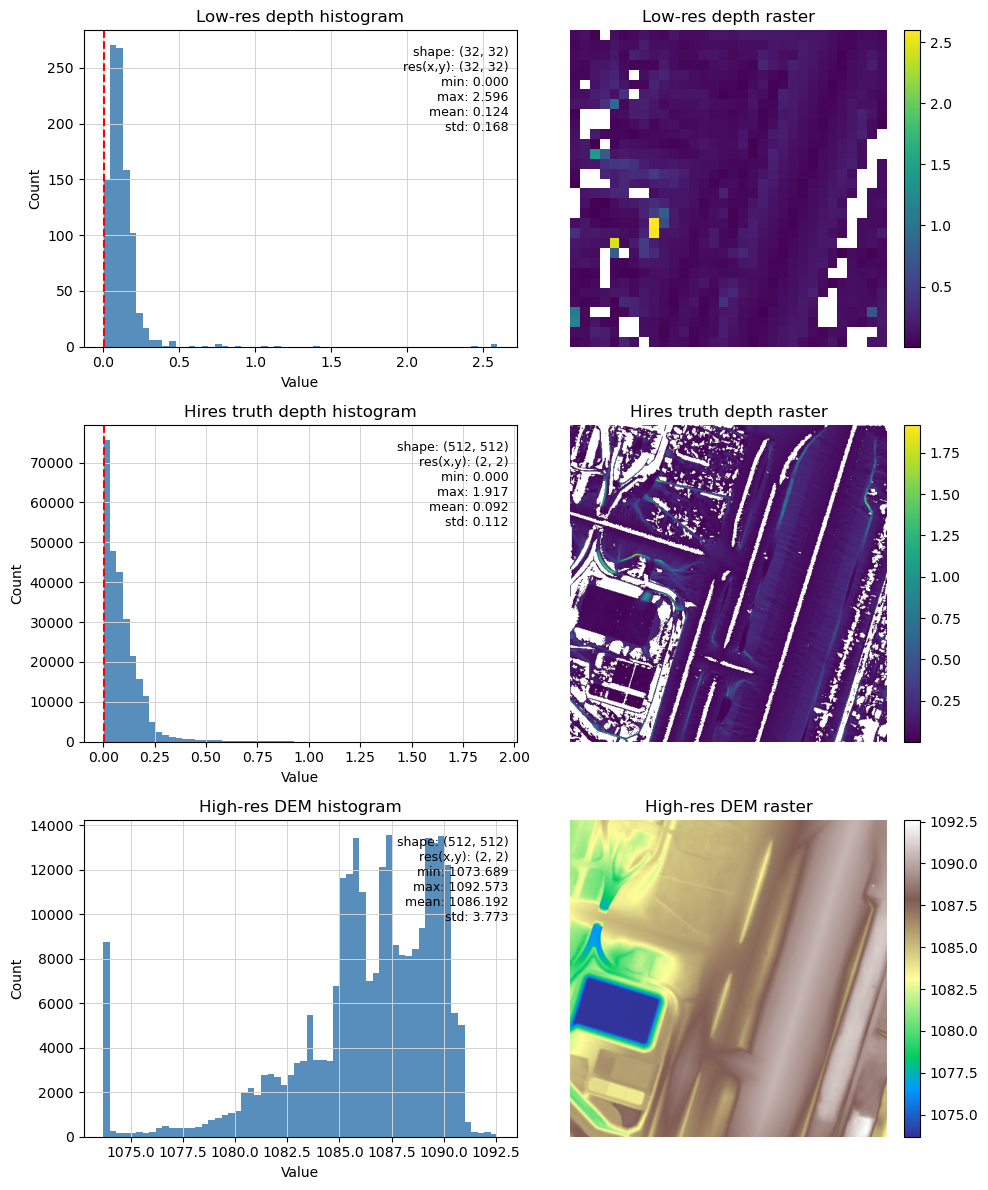

In [8]:
# Plot raw input diagnostics in the same histogram+raster style used in dev/inference.ipynb.
if not HAS_MATPLOTLIB:
    print("matplotlib not available; skipped raw input diagnostics plot.")
else:
    plot_specs_raw = [
        ("Low-res depth", depth_lr_raw, "viridis", True, dry_depth_thresh_m, _pixel_size_m(depth_lr_profile)),
        ("Hires truth depth", depth_hr_truth_raw, "viridis", True, dry_depth_thresh_m, _pixel_size_m(depth_hr_truth_profile)),
        ("High-res DEM", dem_hr_raw, "terrain", False, None, _pixel_size_m(dem_hr_profile)),
    ]

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 12))

    for row_idx, (title, arr, cmap, use_dry_mask, dry_thresh, res_xy) in enumerate(plot_specs_raw):
        arr = np.asarray(arr)
        vals = arr[np.isfinite(arr)]

        ax_hist = axes[row_idx, 0]
        ax_raster = axes[row_idx, 1]

        ax_hist.hist(vals, bins=60, color="steelblue", alpha=0.9)
        if use_dry_mask:
            ax_hist.axvline(dry_thresh, color="red", linestyle="--", linewidth=1.5)
        ax_hist.set_title(f"{title} histogram")
        ax_hist.set_xlabel("Value")
        ax_hist.set_ylabel("Count")
        ax_hist.grid(color="lightgrey", linestyle="-", linewidth=0.7)

        text_lines = [
            f"shape: {arr.shape}",
            f"res(x,y): {_fmt_res(res_xy)}",
            f"min: {vals.min():.3f}",
            f"max: {vals.max():.3f}",
            f"mean: {vals.mean():.3f}",
            f"std: {vals.std():.3f}",
        ]
        ax_hist.text(
            0.98,
            0.95,
            chr(10).join(text_lines),
            transform=ax_hist.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
        )

        raster_arr = np.ma.masked_where(arr < dry_thresh, arr) if use_dry_mask else arr
        im = ax_raster.imshow(raster_arr, cmap=cmap)
        ax_raster.set_title(f"{title} raster")
        ax_raster.set_axis_off()
        fig.colorbar(im, ax=ax_raster, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# VALIDATION

In [9]:
# Compute model and bilinear performance against hires truth and show a comparison table.
metrics_lr = compute_depth_error_metrics(
    reference_depth_m=truth_aligned,
    estimate_depth_m=lr_nearest,
    max_depth=max_depth,
    dry_depth_thresh_m=dry_depth_thresh_m,
)
metrics_bilinear = compute_depth_error_metrics(
    reference_depth_m=truth_aligned,
    estimate_depth_m=lr_bilinear,
    max_depth=max_depth,
    dry_depth_thresh_m=dry_depth_thresh_m,
)
metrics_resunet = compute_depth_error_metrics(
    reference_depth_m=truth_aligned,
    estimate_depth_m=resunet_pred_depth_m,
    max_depth=max_depth,
    dry_depth_thresh_m=dry_depth_thresh_m,
)
metrics_costgrow = None
if costgrow_available:
    metrics_costgrow = compute_depth_error_metrics(
        reference_depth_m=truth_aligned,
        estimate_depth_m=costgrow_pred_depth_m,
        max_depth=max_depth,
        dry_depth_thresh_m=dry_depth_thresh_m,
    )

metric_keys = ["psnr", "ssim", "mase_m", "rmse_m", "rmse_wet_m", "bias_m"]
assert set(metric_keys) == set(params["metric_directionality"]), "metric directionality keys must match metric_keys"
metrics_table_d = {
    resunet_model_version: {k: metrics_resunet[k] for k in metric_keys},
    "Bilinear": {k: metrics_bilinear[k] for k in metric_keys},
}
if costgrow_available:
    metrics_table_d[costgrow_model_version] = {k: metrics_costgrow[k] for k in metric_keys}
metrics_df = pd.DataFrame(metrics_table_d)
metrics_df[f"{resunet_model_version}_minus_Bilinear"] = metrics_df[resunet_model_version] - metrics_df["Bilinear"]
if costgrow_available:
    metrics_df[f"{costgrow_model_version}_minus_Bilinear"] = metrics_df[costgrow_model_version] - metrics_df["Bilinear"]

print(f"Case-spec reference metrics ({case_spec_fp}):")
print(json.dumps(case_spec["expected"], indent=2, sort_keys=True))
print("Notebook-computed metrics:")
display(metrics_df.round(6))


Case-spec reference metrics (/workspace/tests/data/2407_FHIMP_tile/case_spec.json):
{
  "ResUNet_16x_DEM_default": {
    "metrics": {
      "mase_m": 0.0588713426120413,
      "precision": 3,
      "rmse_m": 0.10600513437122326,
      "ssim": 0.6653909680555513
    },
    "params": {
      "min_depth_threshold": 0.01,
      "model_version": "ResUNet_16x_DEM"
    }
  }
}
Notebook-computed metrics:


,ResUNet_16x_DEM,Bilinear,ResUNet_16x_DEM_minus_Bilinear
psnr,33.472862,29.792651,3.680211
ssim,0.665391,0.497398,0.167993
mase_m,0.058871,0.079842,-0.020971
rmse_m,0.106005,0.161934,-0.055929
rmse_wet_m,0.116161,0.156451,-0.040290
bias_m,-0.034232,0.031895,-0.066128


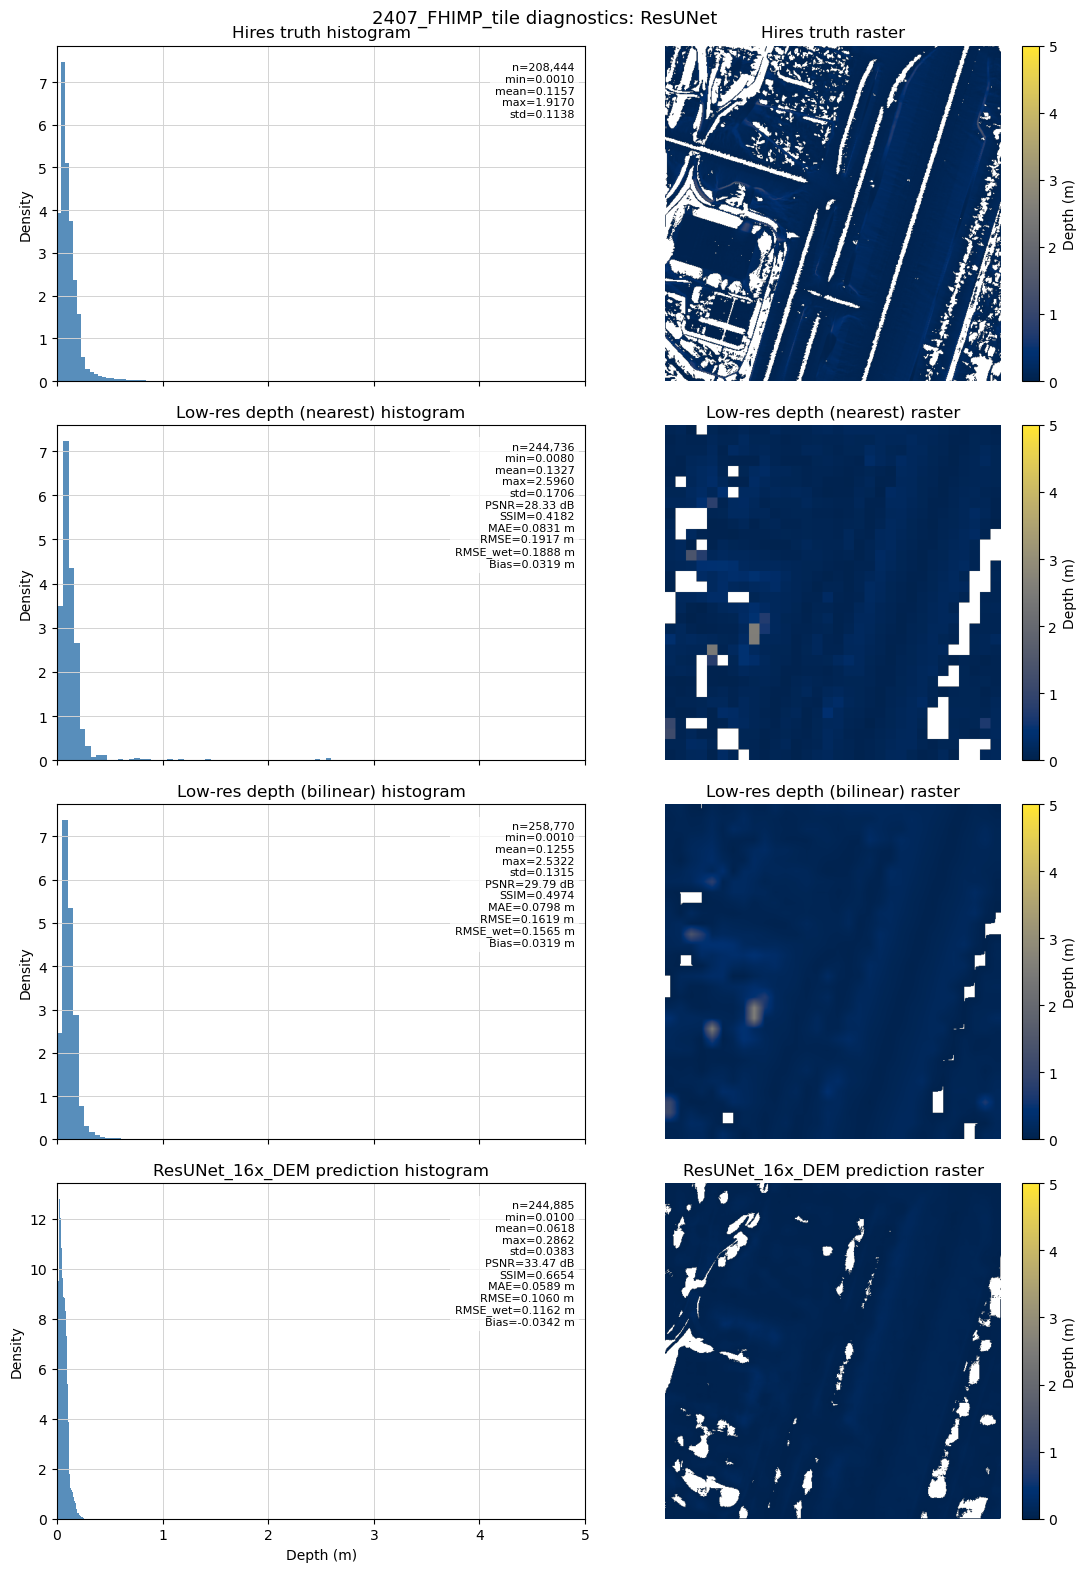

In [10]:
# Render final output comparison with model predictions available in this checkout.
rows = [
    ("Hires truth", truth_aligned, None),
    ("Low-res depth (nearest)", lr_nearest, "lr"),
    ("Low-res depth (bilinear)", lr_bilinear, "bl"),
    (f"{resunet_model_version} prediction", resunet_pred_depth_m, "resunet"),
]
row_metrics = {
    "lr": metrics_lr,
    "bl": metrics_bilinear,
    "resunet": metrics_resunet,
}
vmax_source_l = [truth_aligned, resunet_pred_depth_m]
if costgrow_available:
    rows.append((f"{costgrow_model_version} prediction", costgrow_pred_depth_m, "costgrow"))
    row_metrics["costgrow"] = metrics_costgrow
    vmax_source_l.append(costgrow_pred_depth_m)
vmax_depth = max([float(np.nanmax(arr)) for arr in vmax_source_l] + [max_depth])

if not HAS_MATPLOTLIB:
    print("matplotlib not available; skipped final comparison plot.")
else:
    fig, axes = plt.subplots(nrows=len(rows), ncols=2, figsize=(11, 16), sharex="col")

    for row_idx, (title, img, metric_prefix) in enumerate(rows):
        ax_hist = axes[row_idx, 0]
        ax_img = axes[row_idx, 1]

        masked = np.ma.masked_where(img < dry_depth_thresh_m, img)
        vals = masked.compressed()

        ax_hist.hist(vals, bins=50, density=True, color="steelblue", alpha=0.9)
        ax_hist.axvline(dry_depth_thresh_m, color="red", linestyle="--", linewidth=1.2)
        ax_hist.set_ylabel("Density")
        ax_hist.set_xlim(0.0, vmax_depth)
        ax_hist.grid(color="lightgrey", linestyle="-", linewidth=0.7)
        if row_idx == len(rows) - 1:
            ax_hist.set_xlabel("Depth (m)")

        info_lines = [_stats_text(vals)]
        if metric_prefix is not None:
            metric_group = row_metrics[metric_prefix]
            info_lines.extend(
                [
                    f"PSNR={_fmt_metric(metric_group['psnr'], 2)} dB",
                    f"SSIM={_fmt_metric(metric_group['ssim'])}",
                    f"MAE={_fmt_metric(metric_group['mae_m'])} m",
                    f"RMSE={_fmt_metric(metric_group['rmse_m'])} m",
                    f"RMSE_wet={_fmt_metric(metric_group['rmse_wet_m'])} m",
                    f"Bias={_fmt_metric(metric_group['bias_m'])} m",
                ]
            )

        ax_hist.text(
            0.98,
            0.95,
            chr(10).join(info_lines),
            transform=ax_hist.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 3},
        )
        ax_hist.set_title(f"{title} histogram")

        im = ax_img.imshow(masked, cmap="cividis", vmin=0.0, vmax=vmax_depth)
        ax_img.set_title(f"{title} raster")
        ax_img.set_axis_off()
        fig.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04, label="Depth (m)")

    title_suffix = "ResUNet vs CostGrow" if costgrow_available else "ResUNet"
    fig.suptitle(f"{case_dir.name} diagnostics: {title_suffix}", fontsize=13)
    plt.tight_layout()
    plt.show()
